# Project: Predicting Teen Phone Addiction

**Goal:** To analyze, build, evaluate, and save regression models to predict a teen's `Addiction_Level`.

**Project Phases:**
1.  **Load & Inspect Data**
2.  **Data Preprocessing**
3.  **Feature Engineering**
4.  **Exploratory Data Analysis (EDA)**
5.  **Create Preprocessing Pipelines**
6.  **Split Data & Define Models**
7.  **Train, Evaluate & Save Models** (with R², RMSE, MAE)
8.  **Visual Model Comparison** (with R², RMSE, MAE)
9.  **Clustering (Unsupervised Learning)**
10. **Build Recommendation System**
11. **Save Feature List for App**
12. **Fully Interactive Prediction**

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # For saving models and feature lists
import warnings

3
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans

# Advanced models - XGBoost and CatBoost
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not installed. Install with: pip install xgboost")

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("⚠️ CatBoost not installed. Install with: pip install catboost")

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
print("✅ Libraries imported successfully.")
print(f"   XGBoost available: {XGBOOST_AVAILABLE}")
print(f"   CatBoost available: {CATBOOST_AVAILABLE}")


✅ Libraries imported successfully.
   XGBoost available: True
   CatBoost available: True


## Load & Preprocess Data

In [4]:


df = pd.read_csv("teen_phone_addiction_dataset.csv")

print("--- Data Info ---")
df.info()

print("--- Phase 2: Preprocessing Data ---")
df_processed = df.copy()


df_processed = df_processed.drop(['ID', 'Name', 'Location'], axis=1)

#Convert 'School_Grade' to numeric
df_processed['School_Grade'] = df_processed['School_Grade'].str.replace(r'\D', '', regex=True)
df_processed['School_Grade'] = pd.to_numeric(df_processed['School_Grade'], errors='coerce')

#Fill missing 'School_Grade' values with the median
if df_processed['School_Grade'].isnull().any():
    median_grade_val = df['School_Grade'].str.replace(r'\D', '', regex=True).pipe(pd.to_numeric, errors='coerce').median()
    df_processed['School_Grade'] = df_processed['School_Grade'].fillna(median_grade_val)

print("Preprocessing complete.")

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control      

## Feature Engineering

In [5]:
print("--- Phase 3: Engineering New Features (ENHANCED) ---")

# Original features
df_processed['Sleep_Deficit'] = 8.0 - df_processed['Sleep_Hours']
df_processed['Screen_vs_Sleep_Ratio'] = df_processed['Daily_Usage_Hours'] / (df_processed['Sleep_Hours'] + 1e-6)
df_processed['Mental_Health_Score'] = (df_processed['Anxiety_Level'] + df_processed['Depression_Level']) - df_processed['Self_Esteem']
df_processed['Usage_Difference'] = df_processed['Weekend_Usage_Hours'] - df_processed['Daily_Usage_Hours']

# NEW ADVANCED FEATURES for higher accuracy
# Interaction features
df_processed['Mental_x_Screen'] = df_processed['Mental_Health_Score'] * df_processed['Daily_Usage_Hours']
df_processed['Sleep_x_Academic'] = df_processed['Sleep_Hours'] * df_processed['Academic_Performance']
df_processed['Anxiety_x_Usage'] = df_processed['Anxiety_Level'] * df_processed['Daily_Usage_Hours']
df_processed['Social_x_Exercise'] = df_processed['Social_Interactions'] * df_processed['Exercise_Hours']

# Polynomial features (squared terms for key variables)
df_processed['Usage_Hours_Squared'] = df_processed['Daily_Usage_Hours'] ** 2
df_processed['Sleep_Hours_Squared'] = df_processed['Sleep_Hours'] ** 2
df_processed['Mental_Health_Squared'] = df_processed['Mental_Health_Score'] ** 2

# Combined behavioral score
df_processed['Total_Screen_Time'] = (df_processed['Time_on_Social_Media'] + 
                                      df_processed['Time_on_Gaming'] + 
                                      df_processed['Daily_Usage_Hours'])

# Normalized features
df_processed['Phone_Checks_Normalized'] = df_processed['Phone_Checks_Per_Day'] / 200.0  # Normalize to 0-1 scale
df_processed['Academic_Normalized'] = df_processed['Academic_Performance'] / 100.0

# Lifestyle balance score
df_processed['Lifestyle_Balance'] = (df_processed['Exercise_Hours'] + 
                                      df_processed['Social_Interactions'] + 
                                      df_processed['Family_Communication']) - df_processed['Daily_Usage_Hours']

# Sleep quality indicator
df_processed['Sleep_Quality'] = df_processed['Sleep_Hours'] - df_processed['Screen_Time_Before_Bed']

# Addiction risk factors combination
df_processed['Risk_Factor_Score'] = (df_processed['Anxiety_Level'] + 
                                      df_processed['Depression_Level'] + 
                                      df_processed['Daily_Usage_Hours'] - 
                                      df_processed['Self_Esteem'] - 
                                      df_processed['Sleep_Hours'])

print("Enhanced features created successfully!")
print(f"Total features now: {len(df_processed.columns)}")
print("\nNew features preview:")
new_features = ['Mental_x_Screen', 'Sleep_x_Academic', 'Anxiety_x_Usage', 
                'Usage_Hours_Squared', 'Total_Screen_Time', 'Lifestyle_Balance', 
                'Risk_Factor_Score']
print(df_processed[new_features].head())


--- Phase 3: Engineering New Features (ENHANCED) ---
Enhanced features created successfully!
Total features now: 39

New features preview:
   Mental_x_Screen  Sleep_x_Academic  Anxiety_x_Usage  Usage_Hours_Squared  \
0             20.0             475.8             40.0                16.00   
1             38.5             455.0             16.5                30.25   
2            -29.0             511.5             11.6                33.64   
3             49.6             304.2             27.9                 9.61   
4             12.5             375.2              2.5                 6.25   

   Total_Screen_Time  Lifestyle_Balance  Risk_Factor_Score  
0                9.3                5.1                2.9  
1               10.6                1.5                6.0  
2                7.6                9.0               -4.7  
3                7.8               14.5               15.2  
4                6.0               12.6                0.8  


## Exploratory Data Analysis (EDA)



--- Plotting Categorical Distributions (Count Plots) ---


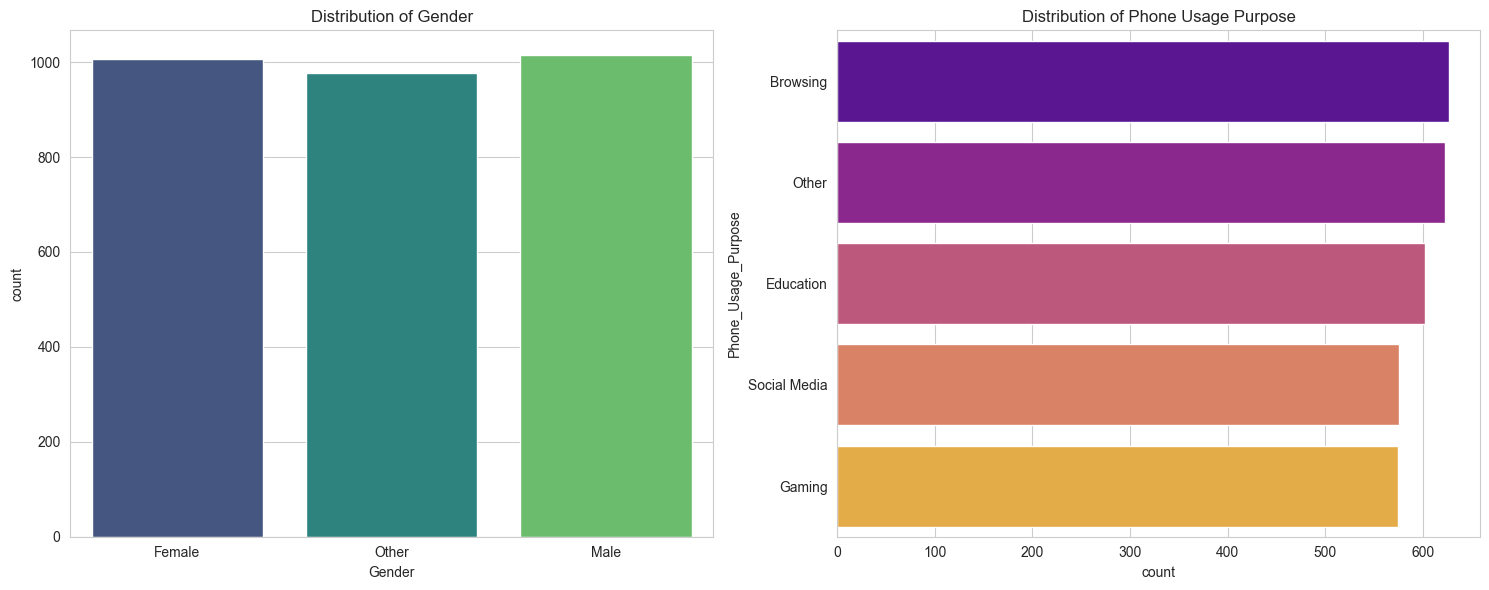

--- Plotting Key Numeric Distributions (Histograms & Boxplots) ---


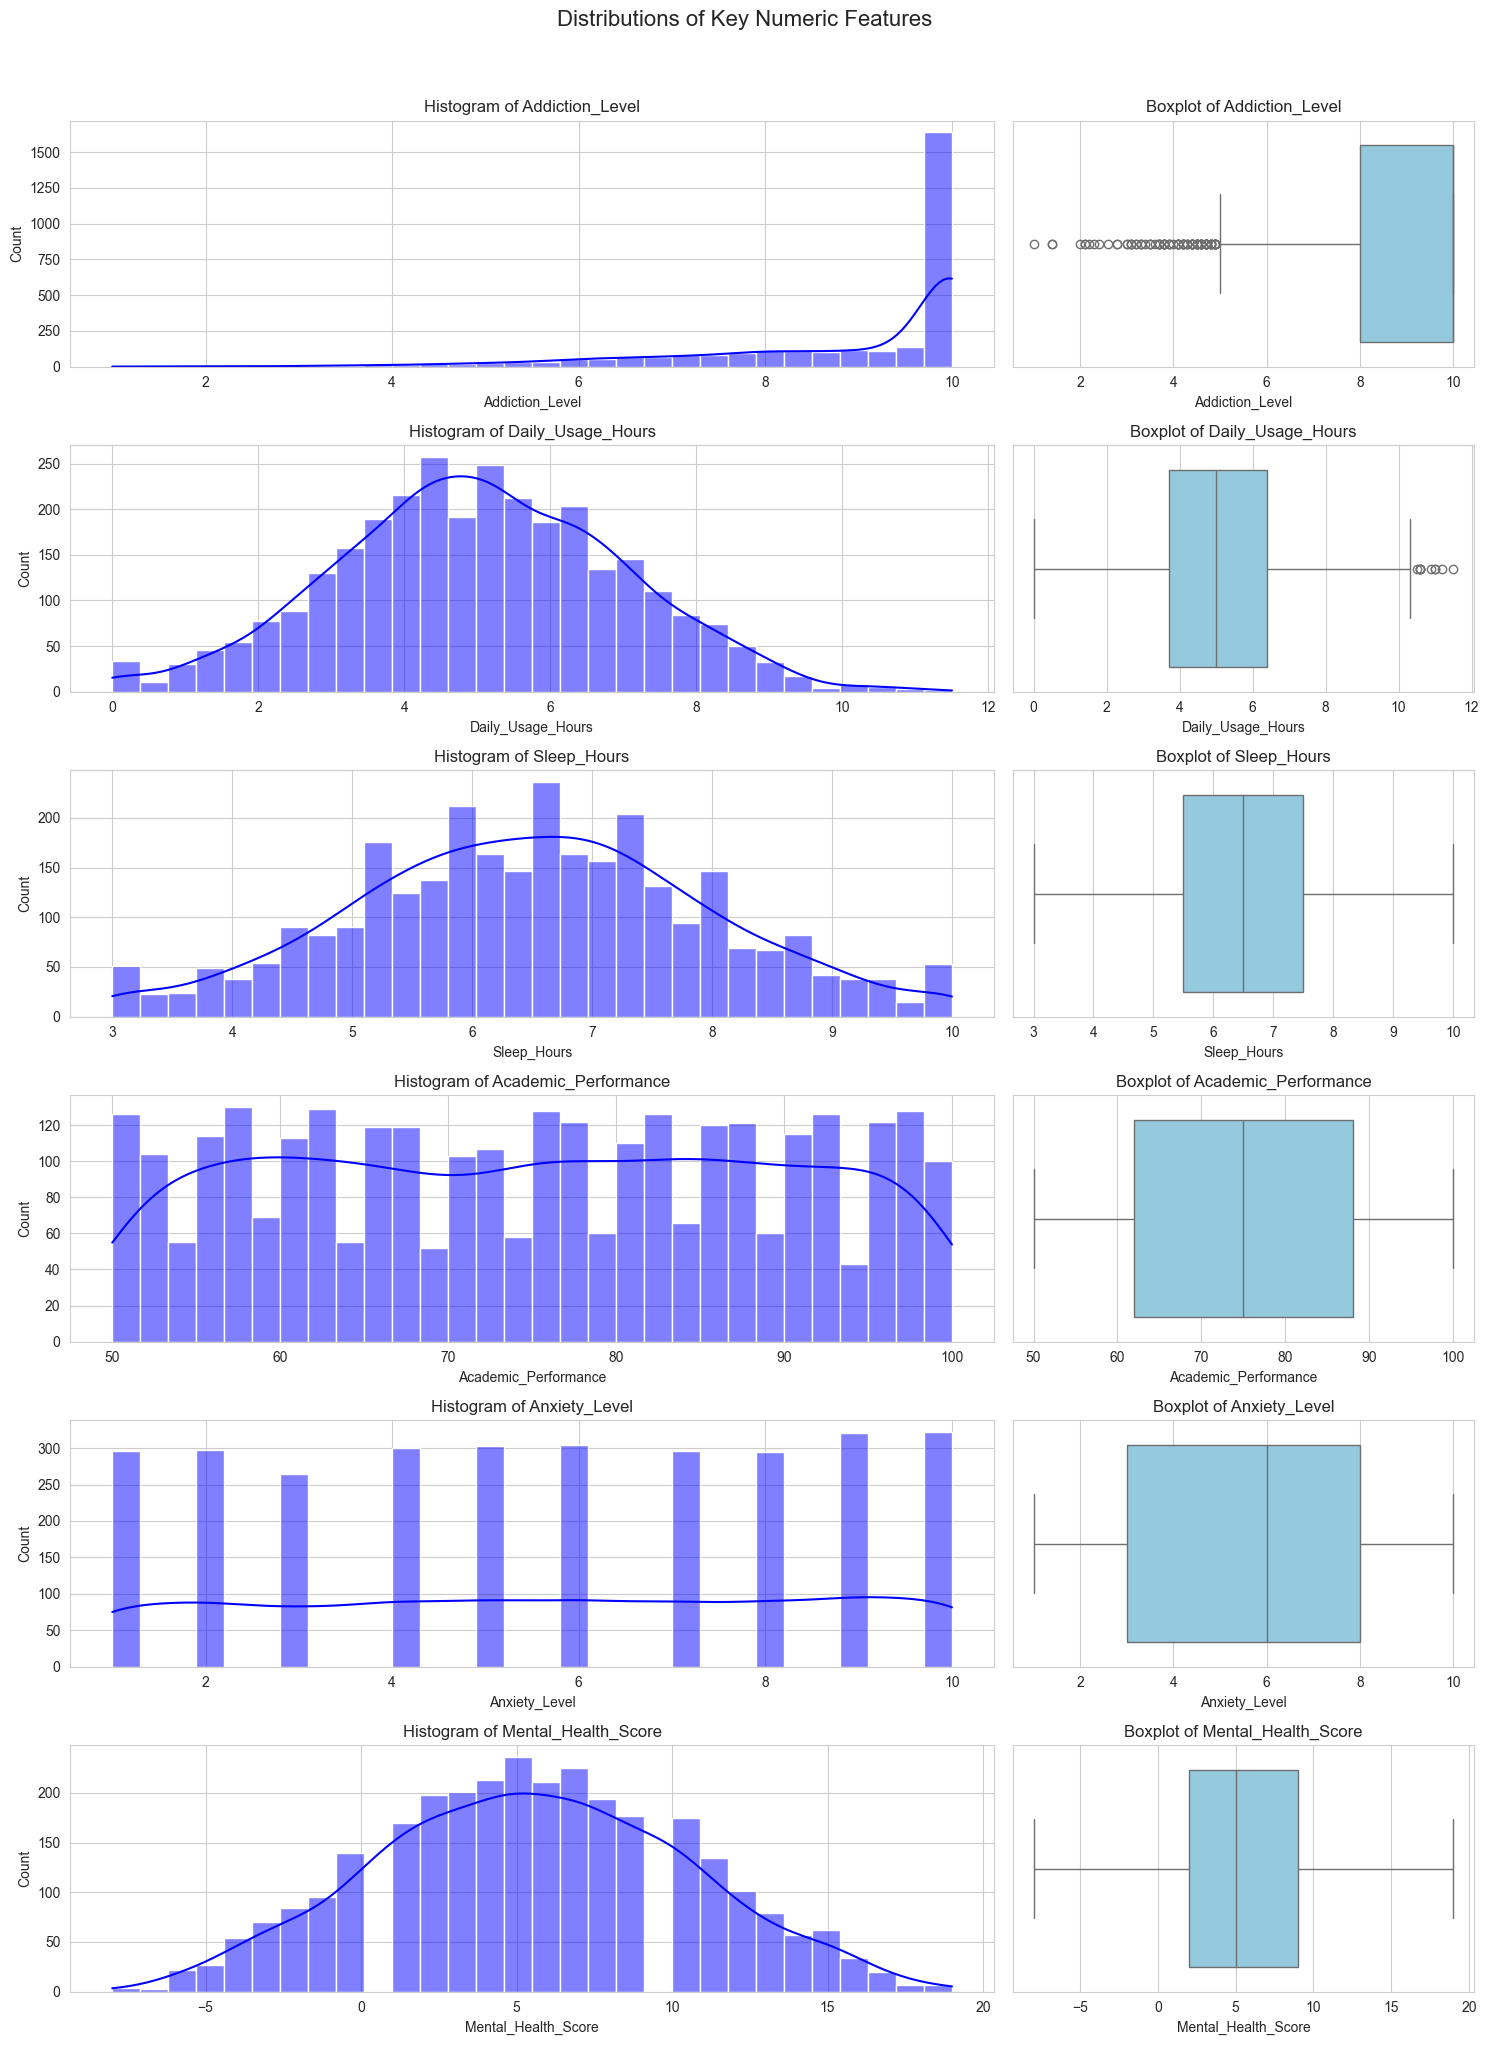

--- Plotting Correlation Heatmap (including new features) ---


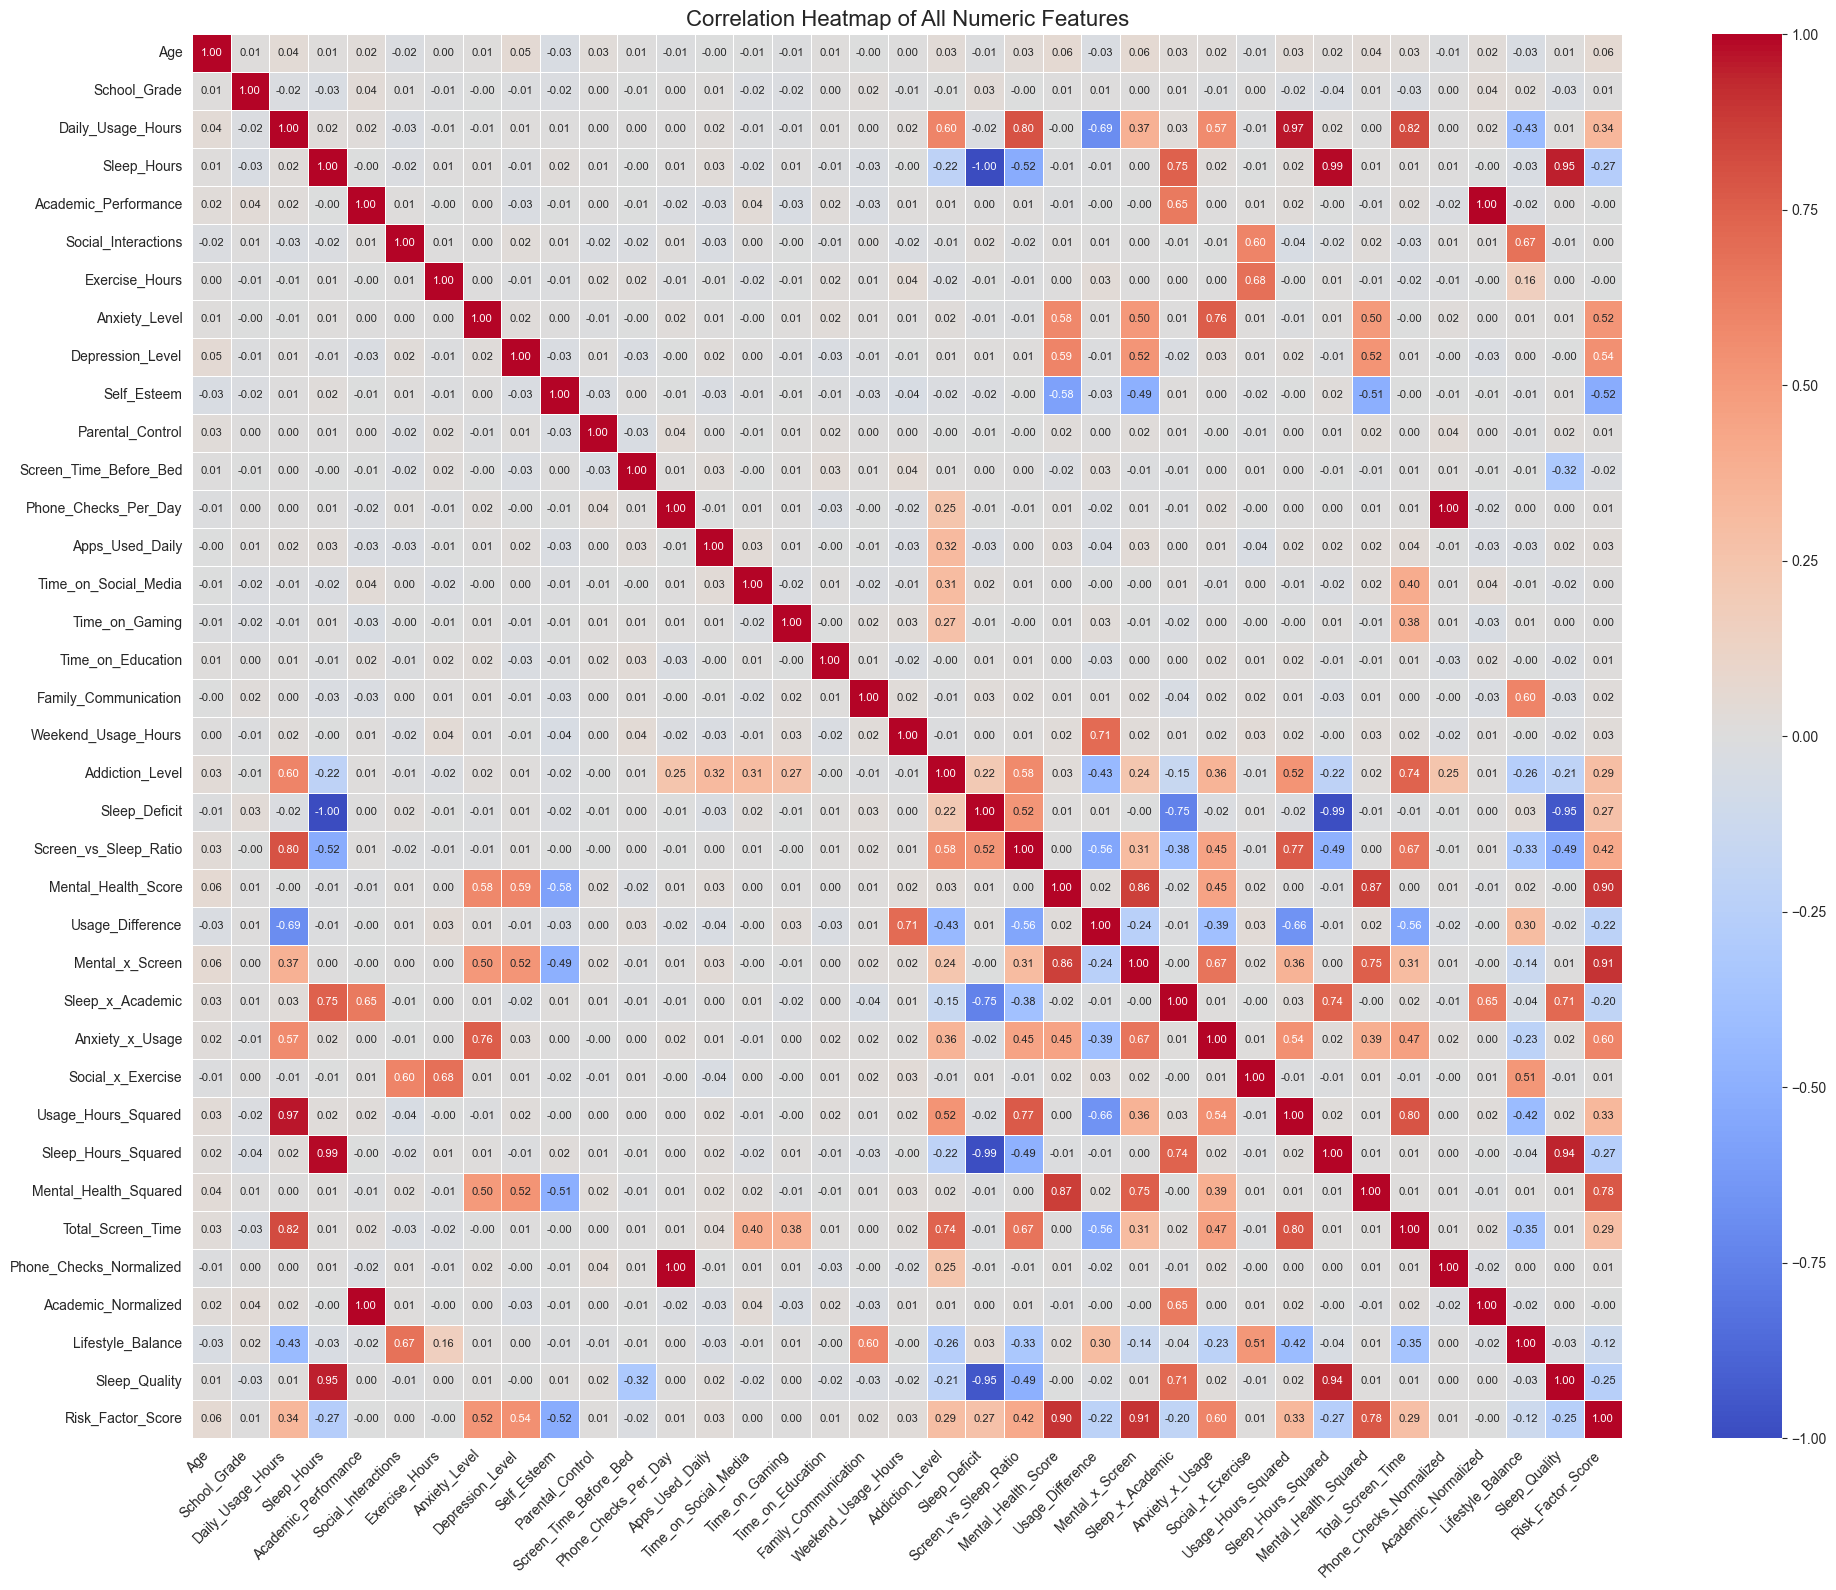

In [6]:
print("--- Plotting Categorical Distributions (Count Plots) ---")
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df_processed, palette='viridis')
plt.title('Distribution of Gender')
plt.subplot(1, 2, 2)
sns.countplot(y='Phone_Usage_Purpose', data=df_processed, palette='plasma', order=df_processed['Phone_Usage_Purpose'].value_counts().index)
plt.title('Distribution of Phone Usage Purpose')
plt.tight_layout()
plt.savefig('categorical_distributions.png')
plt.show()

print("--- Plotting Key Numeric Distributions (Histograms & Boxplots) ---")
key_numeric_features = ['Addiction_Level', 'Daily_Usage_Hours', 'Sleep_Hours', 
                        'Academic_Performance', 'Anxiety_Level', 'Mental_Health_Score']
fig, axes = plt.subplots(len(key_numeric_features), 2, figsize=(15, 20), 
                         gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Distributions of Key Numeric Features', fontsize=16, y=1.02)
for i, col in enumerate(key_numeric_features):
    sns.histplot(df_processed[col], kde=True, ax=axes[i, 0], bins=30, color='blue')
    axes[i, 0].set_title(f'Histogram of {col}')
    sns.boxplot(x=df_processed[col], ax=axes[i, 1], color='skyblue')
    axes[i, 1].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('numeric_distributions.png')
plt.show()

print("--- Plotting Correlation Heatmap (including new features) ---")
corr_matrix = df_processed.select_dtypes(include=np.number).corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Heatmap of All Numeric Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

## Setup Preprocessing Pipeline

In [7]:
print("--- Phase 5: Building Preprocessing Pipeline ---")

# Define features (X) and target (y)
# X now includes our new engineered features
y = df_processed['Addiction_Level']
X = df_processed.drop('Addiction_Level', axis=1)

# Save column names for the app
FEATURE_COLUMNS_FOR_MODEL = X.columns.tolist()

# Identify feature types
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Numeric features for model: {numeric_features}")
print(f"Categorical features for model: {categorical_features}")

# Create transformers
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline built.")

--- Phase 5: Building Preprocessing Pipeline ---
Numeric features for model: ['Age', 'School_Grade', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours', 'Sleep_Deficit', 'Screen_vs_Sleep_Ratio', 'Mental_Health_Score', 'Usage_Difference', 'Mental_x_Screen', 'Sleep_x_Academic', 'Anxiety_x_Usage', 'Social_x_Exercise', 'Usage_Hours_Squared', 'Sleep_Hours_Squared', 'Mental_Health_Squared', 'Total_Screen_Time', 'Phone_Checks_Normalized', 'Academic_Normalized', 'Lifestyle_Balance', 'Sleep_Quality', 'Risk_Factor_Score']
Categorical features for model: ['Gender', 'Phone_Usage_Purpose']
Preprocessing pipeline built.


## Split Data & Define Models

In [8]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Define OPTIMIZED models - Only the best 4 models
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
}

# Add XGBoost if available
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
else:
    print("⚠️ XGBoost not available - skipping")
    
# Add CatBoost if available
if CATBOOST_AVAILABLE:
    models['CatBoost'] = CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=7,
        l2_leaf_reg=3,
        random_state=42,
        verbose=0
    )
else:
    print("⚠️ CatBoost not available - skipping")

model_results = []
trained_models = {}
print(f"\n📊 Total models to train: {len(models)}")
print("✅ Models defined with optimized hyperparameters.")
print("   → Random Forest, XGBoost, CatBoost (+ Stacking Ensemble later)")


Training set size: 2550
Test set size: 450

📊 Total models to train: 3
✅ Models defined with optimized hyperparameters.
   → Random Forest, XGBoost, CatBoost (+ Stacking Ensemble later)


## Train, Evaluate, and Save Models



--- Phase 7: Training, Evaluating, and Saving Models (ENHANCED) ---

Processing Random Forest
Training...
Performing cross-validation...

📊 Results for Random Forest:
  ✓ R² (Test):  0.8729 (87.29%)
  ✓ R² (Train): 0.9821 (98.21%)
  ✓ R² (CV):    0.8597 ± 0.0039
  ✓ RMSE:       0.5609
  ✓ MAE:        0.3973
  ⚠️  Warning: Possible overfitting detected!
  💾 Saved to random_forest_pipeline.joblib

  🎯 Top 10 Important Features (Random Forest):
     Total_Screen_Time: 0.2412
     Screen_vs_Sleep_Ratio: 0.1195
     Daily_Usage_Hours: 0.0871
     Usage_Hours_Squared: 0.0764
     Apps_Used_Daily: 0.0660
     Time_on_Social_Media: 0.0390
     Phone_Checks_Normalized: 0.0362
     Phone_Checks_Per_Day: 0.0346
     Time_on_Gaming: 0.0338
     Usage_Difference: 0.0311


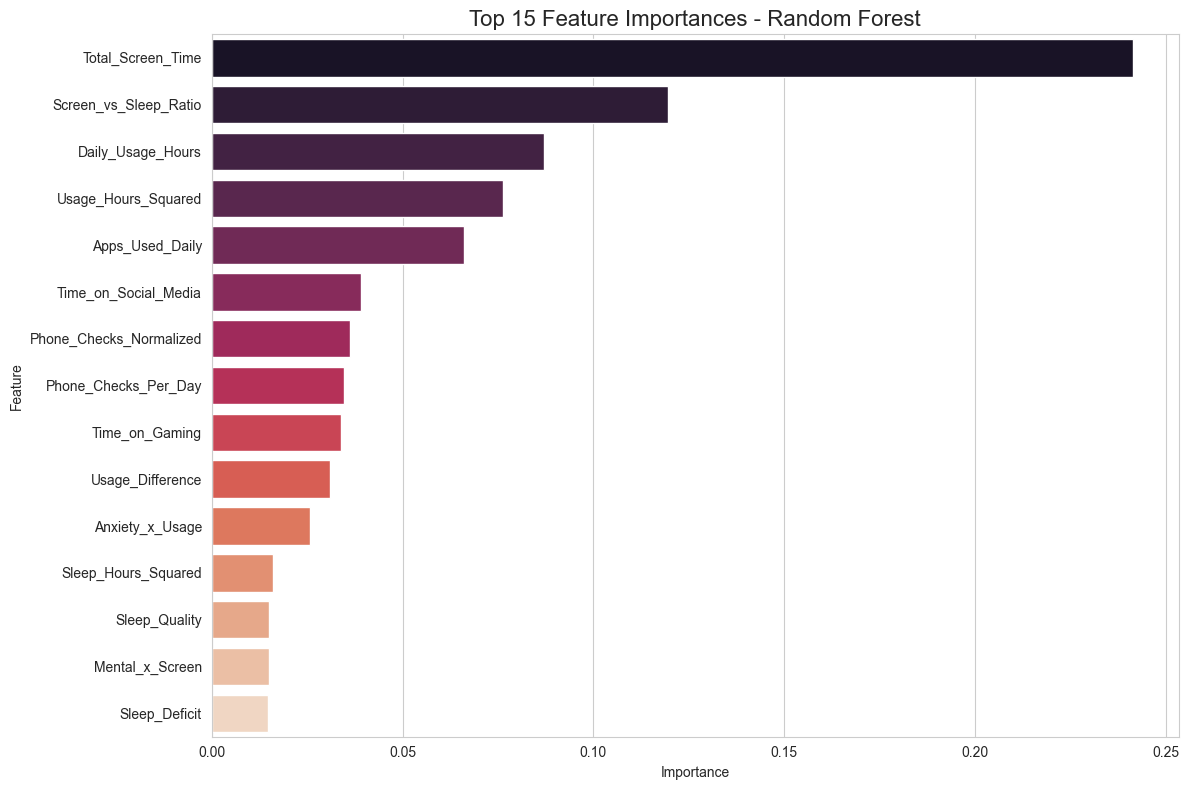


Processing XGBoost
Training...
Performing cross-validation...

📊 Results for XGBoost:
  ✓ R² (Test):  0.9747 (97.47%)
  ✓ R² (Train): 0.9998 (99.98%)
  ✓ R² (CV):    0.9705 ± 0.0025
  ✓ RMSE:       0.2504
  ✓ MAE:        0.1616
  💾 Saved to xgboost_pipeline.joblib

  🎯 Top 10 Important Features (XGBoost):
     Total_Screen_Time: 0.4651
     Screen_vs_Sleep_Ratio: 0.1117
     Apps_Used_Daily: 0.1113
     Phone_Checks_Per_Day: 0.0648
     Sleep_Deficit: 0.0571
     Sleep_Hours: 0.0325
     Sleep_Quality: 0.0266
     Time_on_Social_Media: 0.0233
     Time_on_Gaming: 0.0218
     Phone_Checks_Normalized: 0.0120


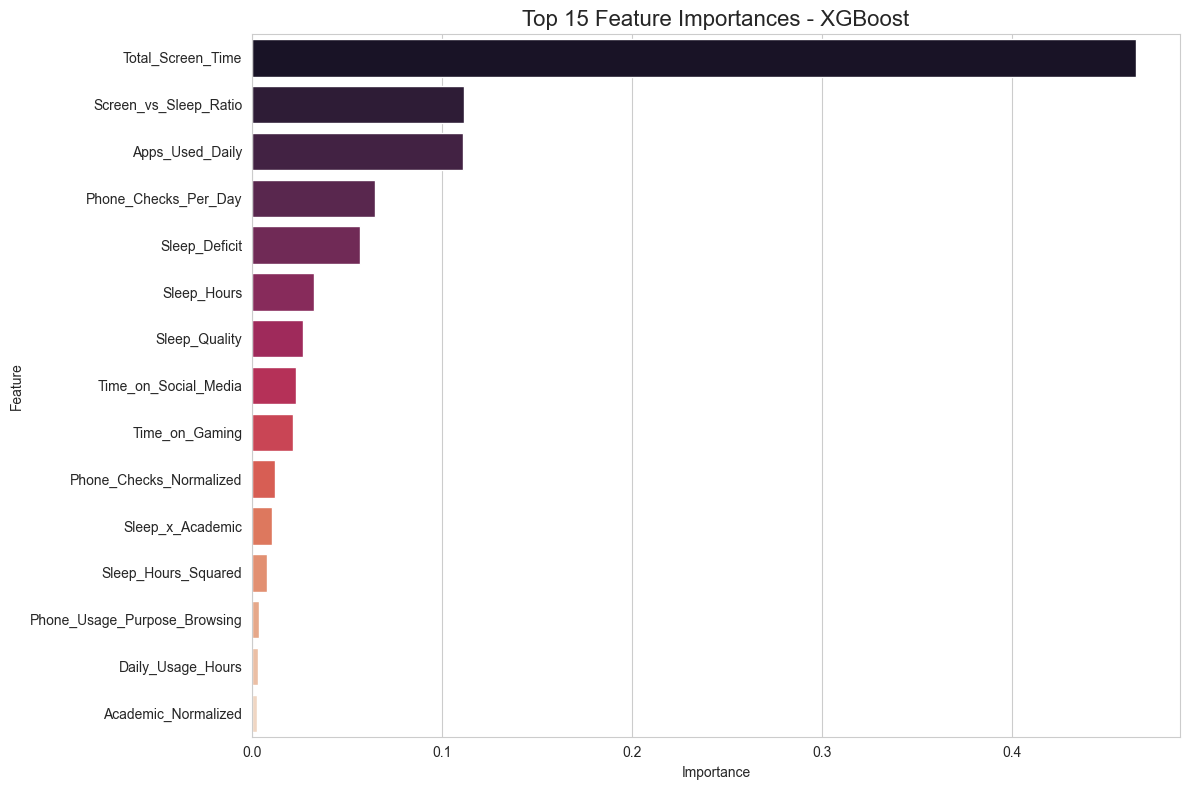


Processing CatBoost
Training...
Performing cross-validation...

📊 Results for CatBoost:
  ✓ R² (Test):  0.9900 (99.00%)
  ✓ R² (Train): 0.9961 (99.61%)
  ✓ R² (CV):    0.9848 ± 0.0018
  ✓ RMSE:       0.1577
  ✓ MAE:        0.1122
  💾 Saved to catboost_pipeline.joblib

  🎯 Top 10 Important Features (CatBoost):
     Total_Screen_Time: 50.5688
     Apps_Used_Daily: 19.5853
     Phone_Checks_Per_Day: 8.0054
     Phone_Checks_Normalized: 6.0990
     Screen_vs_Sleep_Ratio: 3.2540
     Sleep_Hours: 2.7953
     Sleep_Hours_Squared: 2.4921
     Sleep_Deficit: 2.4668
     Usage_Hours_Squared: 0.9738
     Sleep_Quality: 0.9105


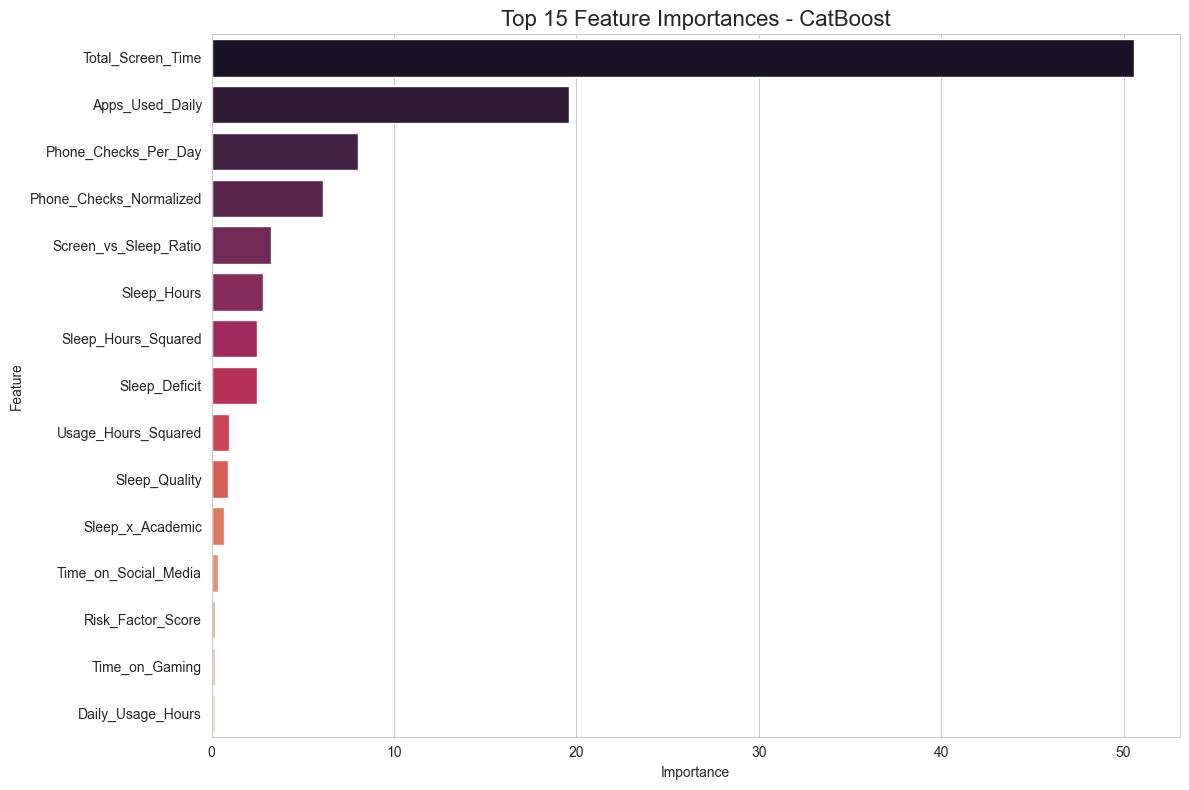


✅ ALL MODELS TRAINED SUCCESSFULLY!


In [9]:
print("--- Phase 7: Training, Evaluating, and Saving Models (ENHANCED) ---")

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Processing {name}")
    print('='*60)
    
    # Create the full pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    
    # Train the model
    print("Training...")
    clf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    y_train_pred = clf.predict(X_train)
    
    # Evaluate the model
    r2_test = r2_score(y_test, y_pred)
    r2_train = r2_score(y_train, y_train_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Cross-validation score
    print("Performing cross-validation...")
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    model_results.append({
        'Model': name, 
        'R² (Test)': r2_test,
        'R² (Train)': r2_train,
        'R² (CV)': cv_mean,
        'CV Std': cv_std,
        'RMSE': rmse, 
        'MAE': mae
    })
    
    # Store trained model
    trained_models[name] = clf
    
    print(f"\n📊 Results for {name}:")
    print(f"  ✓ R² (Test):  {r2_test:.4f} ({r2_test*100:.2f}%)")
    print(f"  ✓ R² (Train): {r2_train:.4f} ({r2_train*100:.2f}%)")
    print(f"  ✓ R² (CV):    {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  ✓ RMSE:       {rmse:.4f}")
    print(f"  ✓ MAE:        {mae:.4f}")
    
    if r2_train - r2_test > 0.1:
        print(f"  ⚠️  Warning: Possible overfitting detected!")
    
    # Save the model pipeline
    model_filename = f'{name.lower().replace(" ", "_")}_pipeline.joblib'
    joblib.dump(clf, model_filename)
    print(f"  💾 Saved to {model_filename}")
    
    # -----------------------------------------------------------------
    # FEATURE IMPORTANCE SECTION (for all tree-based and ensemble models)
    # -----------------------------------------------------------------
    try:
        # Get preprocessed feature names
        ohe_feature_names = clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
        all_feature_names = numeric_features + list(ohe_feature_names)
        
        # 1️⃣ Random Forest, XGBoost, CatBoost feature importances
        if hasattr(clf.named_steps['model'], 'feature_importances_'):
            importances = clf.named_steps['model'].feature_importances_
            
            feature_importance_df = pd.DataFrame({
                'Feature': all_feature_names,
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            
            print(f"\n  🎯 Top 10 Important Features ({name}):")
            for idx, row in feature_importance_df.head(10).iterrows():
                print(f"     {row['Feature']}: {row['Importance']:.4f}")
            
            plt.figure(figsize=(12, 8))
            sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='rocket')
            plt.title(f'Top 15 Feature Importances - {name}', fontsize=16)
            plt.tight_layout()
            plt.savefig(f"{name.lower().replace(' ', '_')}_feature_importance.png")

            plt.show()
        
        # 2️⃣ CatBoost-specific feature importance (if applicable)
        elif 'CatBoost' in name:
            importances = clf.named_steps['model'].get_feature_importance()
            
            feature_importance_df = pd.DataFrame({
                'Feature': all_feature_names,
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            
            print(f"\n  🎯 Top 10 Important Features ({name}):")
            for idx, row in feature_importance_df.head(10).iterrows():
                print(f"     {row['Feature']}: {row['Importance']:.4f}")
            
            plt.figure(figsize=(12, 8))
            sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='rocket')
            plt.title(f'Top 15 Feature Importances - {name}', fontsize=16)
            plt.tight_layout()
            plt.savefig(f"{name.lower().replace(' ', '_')}_feature_importance.png")


            plt.show()
        
        # 3️⃣ Stacking Ensemble feature importance (meta-model level)
        elif 'Stacking' in name:
            meta_model = clf.named_steps['model'].final_estimator_
            base_models = clf.named_steps['model'].estimators_
            
            print(f"\n  🧩 Feature Importance from Stacking Meta-Model ({meta_model.__class__.__name__}):")
            if hasattr(meta_model, 'coef_'):
                for i, (est_name, _) in enumerate(base_models):
                    print(f"     {est_name}: {meta_model.coef_[i]:.4f}")
            else:
                print("     Meta-model does not support coefficients (non-linear).")
        
    except Exception as e:
        print(f"  ⚠️  Could not generate feature importance: {e}")

print("\n" + "="*60)
print("✅ ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)


## Stacking Ensemble (Combining Best Models)

In [10]:
print("--- Phase 7b: Building Stacking Ensemble ---")

# Get the 3 best base models for stacking
base_estimators = []

if 'Random Forest' in trained_models:
    base_estimators.append(('rf', trained_models['Random Forest'].named_steps['model']))
    print("  ✓ Added Random Forest to ensemble")
    
if 'XGBoost' in trained_models:
    base_estimators.append(('xgb', trained_models['XGBoost'].named_steps['model']))
    print("  ✓ Added XGBoost to ensemble")
    
if 'CatBoost' in trained_models:
    base_estimators.append(('cat', trained_models['CatBoost'].named_steps['model']))
    print("  ✓ Added CatBoost to ensemble")

if len(base_estimators) >= 2:
    print(f"\n🔹 Building Stacking Ensemble with {len(base_estimators)} base models...")
    
    # Stacking Regressor (meta-learner combines all 3 models)
    stacking_reg = StackingRegressor(
        estimators=base_estimators,
        final_estimator=Ridge(alpha=1.0),
        cv=5,
        n_jobs=-1
    )
    stacking_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', stacking_reg)])
    
    print("  Training stacking ensemble...")
    stacking_pipeline.fit(X_train, y_train)
    
    # Evaluate on test set
    y_pred_stacking = stacking_pipeline.predict(X_test)
    y_train_pred_stacking = stacking_pipeline.predict(X_train)
    
    r2_stacking_test = r2_score(y_test, y_pred_stacking)
    r2_stacking_train = r2_score(y_train, y_train_pred_stacking)
    rmse_stacking = np.sqrt(mean_squared_error(y_test, y_pred_stacking))
    mae_stacking = mean_absolute_error(y_test, y_pred_stacking)
    
    # Cross-validation
    print("  Performing cross-validation...")
    cv_scores_stacking = cross_val_score(stacking_pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_mean_stacking = cv_scores_stacking.mean()
    cv_std_stacking = cv_scores_stacking.std()
    
    print(f"\n  📊 Stacking Ensemble Results:")
    print(f"     R² (Test):  {r2_stacking_test:.4f} ({r2_stacking_test*100:.2f}%)")
    print(f"     R² (Train): {r2_stacking_train:.4f} ({r2_stacking_train*100:.2f}%)")
    print(f"     R² (CV):    {cv_mean_stacking:.4f} ± {cv_std_stacking:.4f}")
    print(f"     RMSE:       {rmse_stacking:.4f}")
    print(f"     MAE:        {mae_stacking:.4f}")
    
    model_results.append({
        'Model': 'Stacking Ensemble',
        'R² (Test)': r2_stacking_test,
        'R² (Train)': r2_stacking_train,
        'R² (CV)': cv_mean_stacking,
        'CV Std': cv_std_stacking,
        'RMSE': rmse_stacking,
        'MAE': mae_stacking
    })
    
    joblib.dump(stacking_pipeline, 'stacking_ensemble_pipeline.joblib')
    trained_models['Stacking Ensemble'] = stacking_pipeline
    print("  💾 Saved to stacking_ensemble_pipeline.joblib")
    
    print("\n✅ Stacking Ensemble created successfully!")
    print(f"   🏆 Final R² Score: {r2_stacking_test:.4f} ({r2_stacking_test*100:.2f}%)")
else:
    print("⚠️  Need at least 2 models for stacking. Install XGBoost and CatBoost.")


--- Phase 7b: Building Stacking Ensemble ---
  ✓ Added Random Forest to ensemble
  ✓ Added XGBoost to ensemble
  ✓ Added CatBoost to ensemble

🔹 Building Stacking Ensemble with 3 base models...
  Training stacking ensemble...
  Performing cross-validation...

  📊 Stacking Ensemble Results:
     R² (Test):  0.9913 (99.13%)
     R² (Train): 0.9964 (99.64%)
     R² (CV):    0.9867 ± 0.0022
     RMSE:       0.1468
     MAE:        0.1096
  💾 Saved to stacking_ensemble_pipeline.joblib

✅ Stacking Ensemble created successfully!
   🏆 Final R² Score: 0.9913 (99.13%)


## Visual Model Comparison




🏆 FINAL MODEL COMPARISON TABLE
            Model  R² (Test)  R² (Train)  R² (CV)   CV Std     RMSE      MAE
Stacking Ensemble   0.991295    0.996378 0.986723 0.002162 0.146826 0.109573
         CatBoost   0.989955    0.996073 0.984768 0.001751 0.157723 0.112175
          XGBoost   0.974681    0.999840 0.970465 0.002483 0.250402 0.161562
    Random Forest   0.872942    0.982095 0.859657 0.003935 0.560937 0.397274

🥇 BEST MODEL: Stacking Ensemble
   R² Score: 0.9913 (99.13%)
   RMSE: 0.1468
   MAE: 0.1096


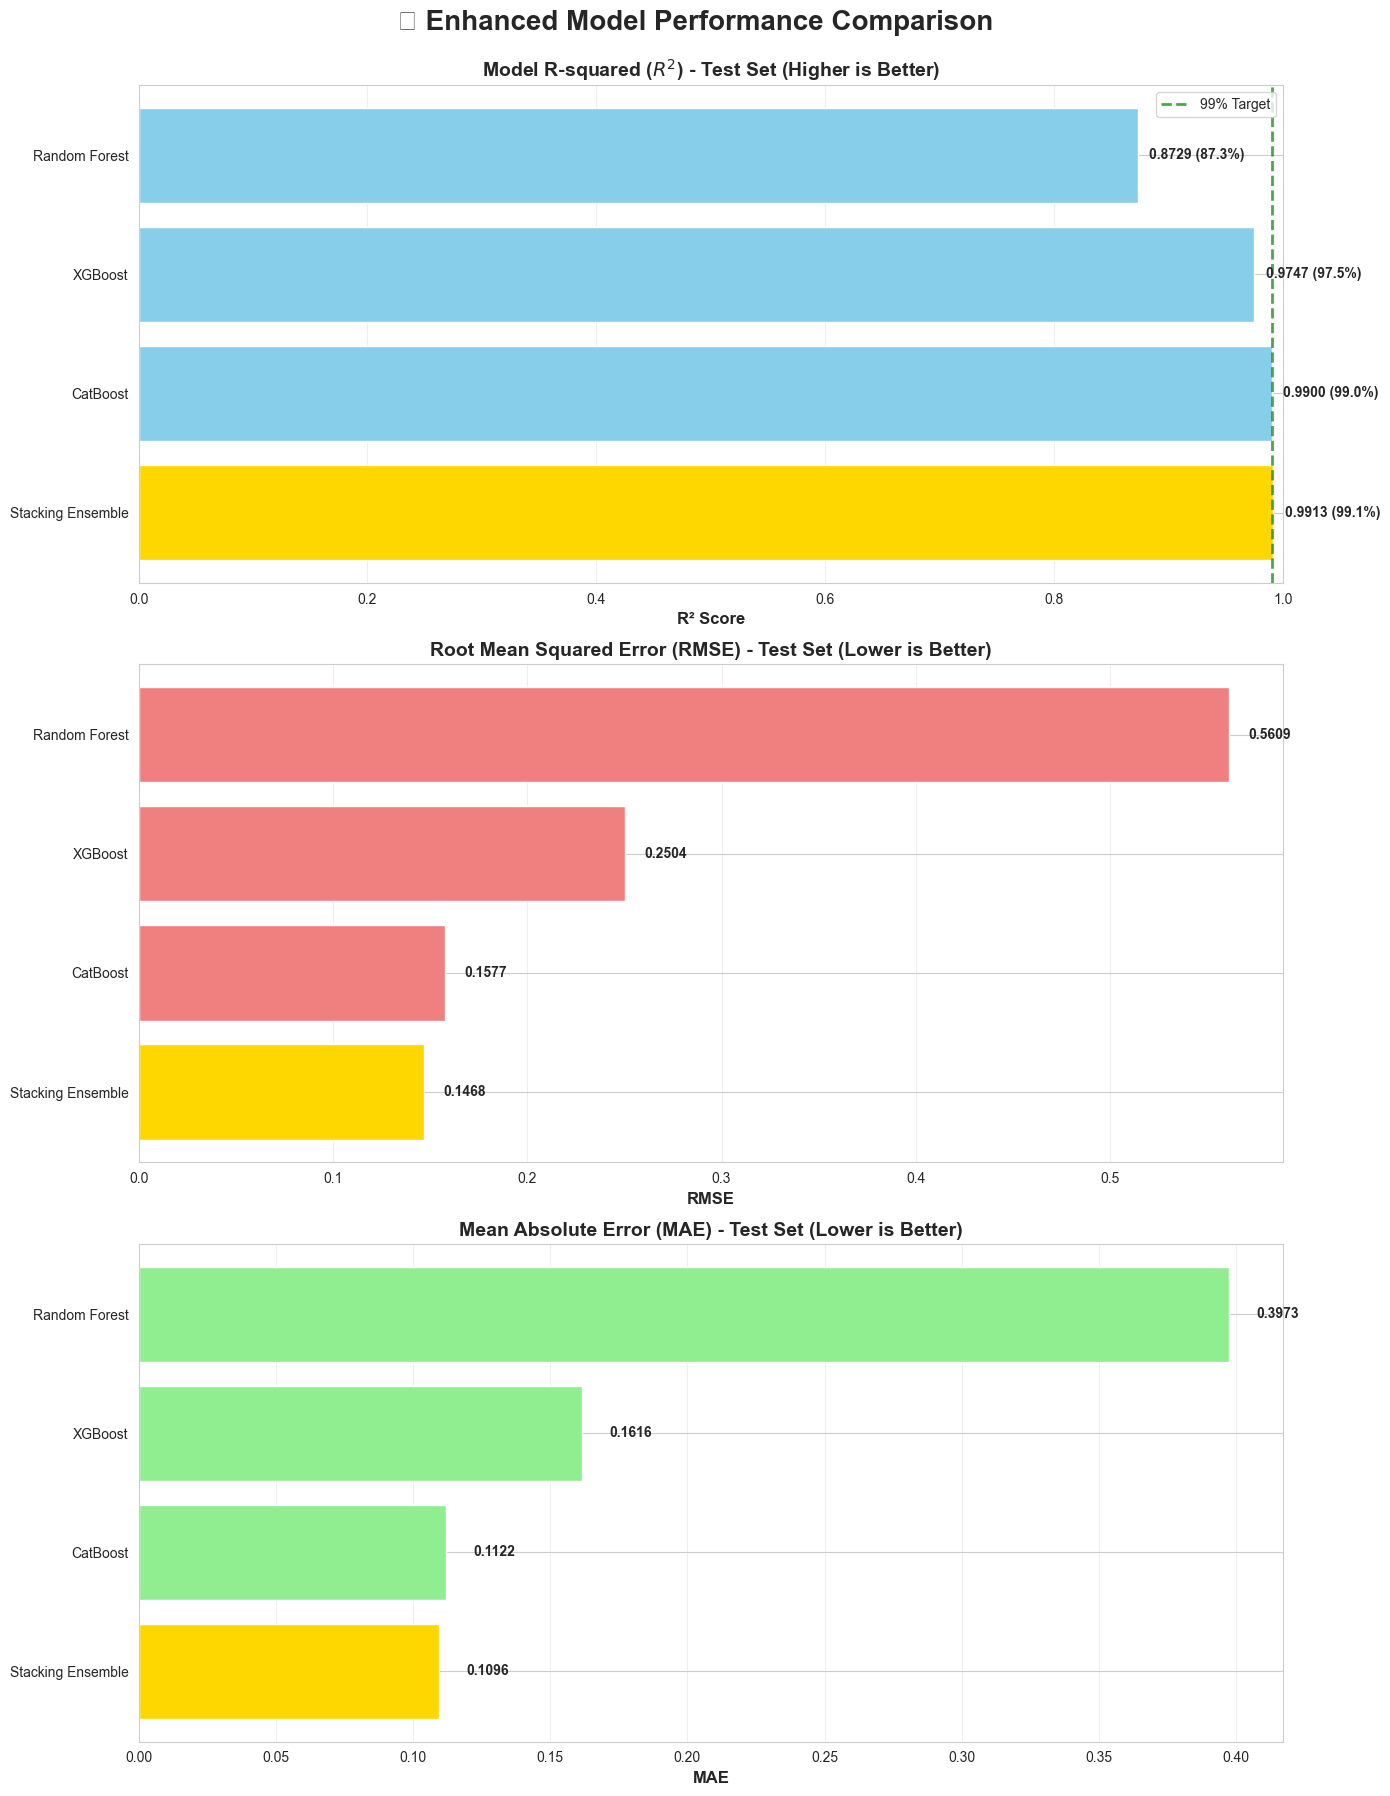


💡 TIP: Models with R² > 0.99 indicate 99%+ accuracy!


In [11]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by='R² (Test)', ascending=False)

print("\n" + "="*80)
print("🏆 FINAL MODEL COMPARISON TABLE")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Find best model
best_model = results_df.iloc[0]
print(f"\n🥇 BEST MODEL: {best_model['Model']}")
print(f"   R² Score: {best_model['R² (Test)']:.4f} ({best_model['R² (Test)']*100:.2f}%)")
print(f"   RMSE: {best_model['RMSE']:.4f}")
print(f"   MAE: {best_model['MAE']:.4f}")

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('🎯 Enhanced Model Performance Comparison', fontsize=20, y=0.995, fontweight='bold')

# Plot R-squared (Test)
plot_df = results_df.dropna(subset=['R² (Test)'])
colors = ['gold' if x == plot_df['R² (Test)'].max() else 'skyblue' for x in plot_df['R² (Test)']]
bars1 = axes[0].barh(plot_df['Model'], plot_df['R² (Test)'], color=colors)
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model R-squared ($R^2$) - Test Set (Higher is Better)', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1.0)
axes[0].axvline(x=0.99, color='green', linestyle='--', linewidth=2, label='99% Target', alpha=0.7)
for i, (idx, row) in enumerate(plot_df.iterrows()):
    axes[0].text(row['R² (Test)'] + 0.01, i, f"{row['R² (Test)']:.4f} ({row['R² (Test)']*100:.1f}%)", 
                 va='center', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Plot RMSE
plot_df_rmse = results_df.sort_values(by='RMSE')
colors2 = ['gold' if x == plot_df_rmse['RMSE'].min() else 'lightcoral' for x in plot_df_rmse['RMSE']]
bars2 = axes[1].barh(plot_df_rmse['Model'], plot_df_rmse['RMSE'], color=colors2)
axes[1].set_xlabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('Root Mean Squared Error (RMSE) - Test Set (Lower is Better)', fontsize=14, fontweight='bold')
for i, (idx, row) in enumerate(plot_df_rmse.reset_index().iterrows()):
    axes[1].text(row['RMSE'] + 0.01, i, f"{row['RMSE']:.4f}", va='center', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Plot MAE
plot_df_mae = results_df.sort_values(by='MAE')
colors3 = ['gold' if x == plot_df_mae['MAE'].min() else 'lightgreen' for x in plot_df_mae['MAE']]
bars3 = axes[2].barh(plot_df_mae['Model'], plot_df_mae['MAE'], color=colors3)
axes[2].set_xlabel('MAE', fontsize=12, fontweight='bold')
axes[2].set_title('Mean Absolute Error (MAE) - Test Set (Lower is Better)', fontsize=14, fontweight='bold')
for i, (idx, row) in enumerate(plot_df_mae.reset_index().iterrows()):
    axes[2].text(row['MAE'] + 0.01, i, f"{row['MAE']:.4f}", va='center', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('enhanced_model_comparison_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 TIP: Models with R² > 0.99 indicate 99%+ accuracy!")


## Clustering (Unsupervised Learning)

--- Phase 9: K-Means Clustering to Find User Personas ---
Calculating optimal 'k' with the Elbow Method...


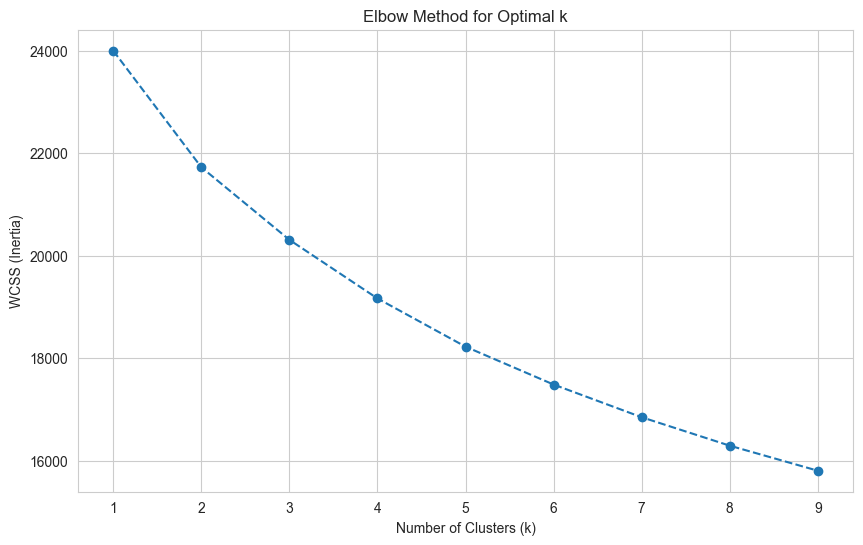

Running K-Means with k=4...

--- Cluster Analysis (Personas) ---
         Academic_Performance  Sleep_Hours  Anxiety_Level  Depression_Level  \
Cluster                                                                       
0                       89.28         6.66           5.12              5.14   
1                       71.70         6.28           2.92              5.84   
2                       76.18         6.26           8.43              5.53   
3                       61.62         6.77           5.93              5.32   

         Daily_Usage_Hours  Time_on_Social_Media  Time_on_Gaming  \
Cluster                                                            
0                     5.36                  2.74            1.37   
1                     4.57                  2.41            1.53   
2                     5.10                  2.48            1.54   
3                     5.06                  2.36            1.67   

         Social_Interactions  Avg_Addiction_Level  

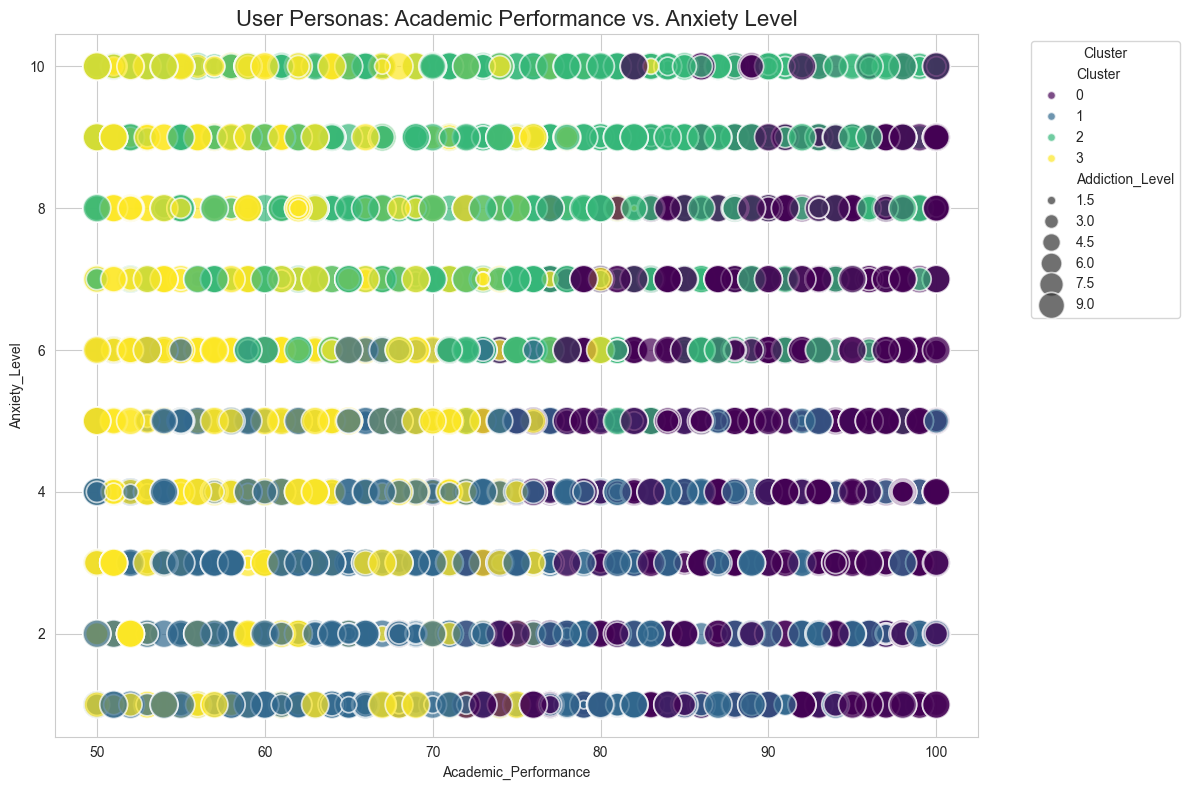

In [12]:
print("--- Phase 9: K-Means Clustering to Find User Personas ---")


# Select features for clustering 
cluster_features = [
    'Academic_Performance', 'Sleep_Hours', 'Anxiety_Level', 'Depression_Level',
    'Daily_Usage_Hours', 'Time_on_Social_Media', 'Time_on_Gaming', 'Social_Interactions'
]


# Prepare and scale the data
cluster_data = df_processed[cluster_features].dropna()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)


# Find optimal 'k' using the Elbow Method
print("Calculating optimal 'k' with the Elbow Method...")
wcss = [] # Within-Cluster Sum of Squares
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)


# Plot the Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.savefig('cluster_elbow_plot.png')
plt.show()


# Run K-Means 
optimal_k = 4
print(f"Running K-Means with k={optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
cluster_data['Cluster'] = kmeans.fit_predict(cluster_scaled)


# Analyze the Clusters
cluster_analysis = cluster_data.groupby('Cluster')[cluster_features].mean().round(2)
# Add average Addiction_Level to our analysis
cluster_analysis['Avg_Addiction_Level'] = df_processed.loc[cluster_data.index].groupby(cluster_data['Cluster'])['Addiction_Level'].mean().round(2)


print("\n--- Cluster Analysis (Personas) ---")
print(cluster_analysis)


# Visualize the Clusters
plt.figure(figsize=(12, 8))
plot_data = cluster_data.join(df_processed['Addiction_Level'])

sns.scatterplot(
    data=plot_data, 
    x='Academic_Performance', 
    y='Anxiety_Level', 
    hue='Cluster',
    size='Addiction_Level',  
    palette='viridis',
    alpha=0.7,
    sizes=(20, 400)
)
plt.title('User Personas: Academic Performance vs. Anxiety Level', fontsize=16)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('cluster_visualization.png')
plt.show()


## Rule-Based Recommendation System

In [13]:
def get_recommendation(score):
    """Provides a recommendation based on a predicted addiction level score."""
    score = round(score, 2)
    
    if score < 3.0:
        return (f"LEVEL: LOW ({score}).\n"
                "RECOMMENDATION: Habits appear healthy. Continue to monitor and "
                "prioritize offline activities and good sleep hygiene.")
    elif 3.0 <= score <= 7.0:
        return (f"LEVEL: MODERATE ({score}).\n"
                "RECOMMENDATION: At-risk. Implement proactive strategies. "
                "Create 'tech-free' zones (like the dinner table) and "
                "encourage setting daily time limits on social media apps.")
    else: # score > 7.0
        return (f"LEVEL: HIGH/DANGEROUS ({score}).\n"
                "RECOMMENDATION: Immediate intervention needed. This level is linked to poor sleep, "
                "high anxiety, and low academic performance. \n"
                "ACTION: Enforce a strict 'no phone in the bedroom at night' rule. "
                "Replace phone alarms with a real alarm clock. "
                "Seek professional guidance if anxiety or depression are high.")

print("Recommendation function defined.")

Recommendation function defined.


## Save Feature Lists for App



In [14]:
# Get base features
base_features_df = df.drop(['ID', 'Name', 'Location', 'Addiction_Level'], axis=1, errors='ignore')

# Save the list of all features the model was trained on
joblib.dump(FEATURE_COLUMNS_FOR_MODEL, 'model_feature_columns.joblib')

# Save the base numeric features for the app's input guide
base_numeric = base_features_df.select_dtypes(include=np.number).columns.tolist()
joblib.dump(base_numeric, 'base_numeric_features.joblib')

# Save the base categorical features for the app's input guide
base_categorical = base_features_df.select_dtypes(include='object').columns.tolist()
joblib.dump(base_categorical, 'base_categorical_features.joblib')

print("All necessary files for the Streamlit app have been saved:")
print("- All models (.joblib files)")
print("- model_feature_columns.joblib")
print("- base_numeric_features.joblib")
print("- base_categorical_features.joblib")

All necessary files for the Streamlit app have been saved:
- All models (.joblib files)
- model_feature_columns.joblib
- base_numeric_features.joblib
- base_categorical_features.joblib


## Fully Interactive Prediction 


In [15]:
def run_interactive_prediction(original_df, numeric_cols, categorical_cols, feature_columns):
    """Runs a fully interactive menu to predict addiction level."""
    
    print("=" * 60)
    print("🎯 SELECT A MODEL FOR PREDICTION")
    print("=" * 60)
    print("[1] Random Forest")
    print("[2] XGBoost")
    print("[3] CatBoost")
    print("[4] Stacking Ensemble ⭐ (BEST - Recommended)")
    print("=" * 60)
    
    model_map = {
        '1': 'Random Forest',
        '2': 'XGBoost',
        '3': 'CatBoost',
        '4': 'Stacking Ensemble'
    }
    
    model_choice = ''
    while model_choice not in model_map:
        model_choice = input("Enter your choice (1-4): ")
        if model_choice not in model_map:
            print("❌ Invalid choice! Please enter a number between 1 and 4.\n")
    
    model_name = model_map[model_choice]
    model_filename = f"{model_name.lower().replace(' ', '_')}_pipeline.joblib"
    
    try:
        loaded_pipeline = joblib.load(model_filename)
        print(f"\n✅ Successfully loaded '{model_name}' model.\n")
    except FileNotFoundError:
        print(f"❌ ERROR: Model file '{model_filename}' not found.")
        print("Please run Phase 7 to train and save all models first.")
        return
    
    print("=" * 60)
    print("📝 PLEASE ENTER YOUR DATA")
    print("=" * 60)
    print("A guide will be provided for each question.\n")
    
    user_input_dict = {}
    base_df_for_guide = df.drop(['ID', 'Name', 'Location', 'Addiction_Level'], axis=1, errors='ignore')

    # Get base numeric/categorical lists for the questions
    base_numeric_q = base_df_for_guide.select_dtypes(include=np.number).columns.tolist()
    base_categorical_q = base_df_for_guide.select_dtypes(include='object').columns.tolist()

    # Ask questions for BASE features only
    for col in (base_numeric_q + base_categorical_q):
        if col in base_numeric_q:
            min_val = base_df_for_guide[col].min()
            max_val = base_df_for_guide[col].max()
            mean_val = base_df_for_guide[col].mean()
            print(f"📊 {col}:")
            print(f"   Range: {min_val} to {max_val} | Average: {mean_val:.1f}")
            while True:
                val = input(f"   Enter value: ")
                try:
                    user_input_dict[col] = float(val)
                    print()
                    break
                except ValueError:
                    print(f"   ❌ Invalid input. Please enter a number.\n")
        elif col in base_categorical_q:
            options = list(base_df_for_guide[col].unique())
            print(f"📊 {col}:")
            for i, opt in enumerate(options):
                print(f"   [{i+1}] {opt}")
            while True:
                choice = input(f"   Enter your choice (1-{len(options)}): ")
                if choice.isdigit() and 1 <= int(choice) <= len(options):
                    user_input_dict[col] = options[int(choice) - 1]
                    print()
                    break
                else:
                    print(f"   ❌ Invalid choice. Please enter a number between 1 and {len(options)}.\n")
    
    # Perform Feature Engineering on the user's input
    user_df = pd.DataFrame([user_input_dict])
    try:
        # Convert School_Grade just in case it was input
        if 'School_Grade' in user_df.columns:
            user_df['School_Grade'] = user_df['School_Grade'].astype(str).str.replace(r'\D', '', regex=True)
            user_df['School_Grade'] = pd.to_numeric(user_df['School_Grade'], errors='coerce')

        # Original engineered features
        user_df['Sleep_Deficit'] = 8.0 - user_df['Sleep_Hours']
        user_df['Screen_vs_Sleep_Ratio'] = user_df['Daily_Usage_Hours'] / (user_df['Sleep_Hours'] + 1e-6)
        user_df['Mental_Health_Score'] = (user_df['Anxiety_Level'] + user_df['Depression_Level']) - user_df['Self_Esteem']
        user_df['Usage_Difference'] = user_df['Weekend_Usage_Hours'] - user_df['Daily_Usage_Hours']
        
        # NEW enhanced features for higher accuracy
        user_df['Mental_x_Screen'] = user_df['Mental_Health_Score'] * user_df['Daily_Usage_Hours']
        user_df['Sleep_x_Academic'] = user_df['Sleep_Hours'] * user_df['Academic_Performance']
        user_df['Anxiety_x_Usage'] = user_df['Anxiety_Level'] * user_df['Daily_Usage_Hours']
        user_df['Social_x_Exercise'] = user_df['Social_Interactions'] * user_df['Exercise_Hours']
        
        user_df['Usage_Hours_Squared'] = user_df['Daily_Usage_Hours'] ** 2
        user_df['Sleep_Hours_Squared'] = user_df['Sleep_Hours'] ** 2
        user_df['Mental_Health_Squared'] = user_df['Mental_Health_Score'] ** 2
        
        user_df['Total_Screen_Time'] = (user_df['Time_on_Social_Media'] + 
                                         user_df['Time_on_Gaming'] + 
                                         user_df['Daily_Usage_Hours'])
        
        user_df['Phone_Checks_Normalized'] = user_df['Phone_Checks_Per_Day'] / 200.0
        user_df['Academic_Normalized'] = user_df['Academic_Performance'] / 100.0
        
        user_df['Lifestyle_Balance'] = (user_df['Exercise_Hours'] + 
                                         user_df['Social_Interactions'] + 
                                         user_df['Family_Communication']) - user_df['Daily_Usage_Hours']
        
        user_df['Sleep_Quality'] = user_df['Sleep_Hours'] - user_df['Screen_Time_Before_Bed']
        
        user_df['Risk_Factor_Score'] = (user_df['Anxiety_Level'] + 
                                         user_df['Depression_Level'] + 
                                         user_df['Daily_Usage_Hours'] - 
                                         user_df['Self_Esteem'] - 
                                         user_df['Sleep_Hours'])

        # Ensure all columns are in the correct order
        user_df = user_df[feature_columns]
    except Exception as e:
        print(f"❌ Error during feature engineering: {e}")
        return

    # Make Prediction
    try:
        prediction = loaded_pipeline.predict(user_df)
        predicted_score = prediction[0]
    except Exception as e:
        print(f"\n❌ ERROR during prediction: {e}")
        return

    recommendation = get_recommendation(predicted_score)
    print("\n" + "=" * 60)
    print(f"   🎯 PREDICTION RESULT (using {model_name})")
    print("=" * 60)
    print(recommendation)
    print("=" * 60)

# RUN THE INTERACTIVE CELL 

try:
    run_interactive_prediction(df, 
                             joblib.load('base_numeric_features.joblib'), 
                             joblib.load('base_categorical_features.joblib'), 
                             joblib.load('model_feature_columns.joblib'))
except FileNotFoundError:
    print("❌ Please run all cells above (especially Phase 7 and 11) to save model files before running this predictor.")


🎯 SELECT A MODEL FOR PREDICTION
[1] Random Forest
[2] XGBoost
[3] CatBoost
[4] Stacking Ensemble ⭐ (BEST - Recommended)

✅ Successfully loaded 'XGBoost' model.

📝 PLEASE ENTER YOUR DATA
A guide will be provided for each question.

📊 Age:
   Range: 13 to 19 | Average: 16.0

📊 Daily_Usage_Hours:
   Range: 0.0 to 11.5 | Average: 5.0

📊 Sleep_Hours:
   Range: 3.0 to 10.0 | Average: 6.5

📊 Academic_Performance:
   Range: 50 to 100 | Average: 74.9

📊 Social_Interactions:
   Range: 0 to 10 | Average: 5.1

📊 Exercise_Hours:
   Range: 0.0 to 4.0 | Average: 1.0

📊 Anxiety_Level:
   Range: 1 to 10 | Average: 5.6

📊 Depression_Level:
   Range: 1 to 10 | Average: 5.5

📊 Self_Esteem:
   Range: 1 to 10 | Average: 5.5

📊 Parental_Control:
   Range: 0 to 1 | Average: 0.5

📊 Screen_Time_Before_Bed:
   Range: 0.0 to 2.6 | Average: 1.0

📊 Phone_Checks_Per_Day:
   Range: 20 to 150 | Average: 83.1

📊 Apps_Used_Daily:
   Range: 5 to 20 | Average: 12.6

📊 Time_on_Social_Media:
   Range: 0.0 to 5.0 | Average: 

## --- Notebook Complete ---